In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("guns.csv")

df.head()

,Category,Name,Type,Rating,Cost,Sale Cost,Description
0,Assault Rifles,Assault Rifle Bullets,NaN,NaN,6.0,NaN,NaN
1,Assault Rifles,OCP-11,Full-Auto Assaut Rifle,1.0,NaN,NaN,NaN
2,Assault Rifles,416,Full-Auto Assaut Rifle,2.0,NaN,NaN,The 416 is a well-built German assaut rifle. A...
3,Assault Rifles,417,Burst-Fire Assault Rifle,3.0,7500.0,NaN,The 417 is a German-made semi-automatic assaul...
4,Assault Rifles,AK-47,Full-Auto Assaut Rifle,3.0,NaN,NaN,The AK-47 is known for its durability and simp...


In [3]:
print(df.info())
print(df.isnull().sum())

df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Category     36 non-null     str    
 1   Name         36 non-null     str    
 2   Type         31 non-null     str    
 3   Rating       31 non-null     float64
 4   Cost         17 non-null     float64
 5   Sale Cost    2 non-null      float64
 6   Description  5 non-null      str    
dtypes: float64(3), str(4)
memory usage: 3.9 KB
None
Category        0
Name            0
Type            5
Rating          5
Cost           19
Sale Cost      34
Description    31
dtype: int64


,Category,Name,Type,Rating,Cost,Sale Cost,Description
count,36,36,31,31.000000,17.000000,2.000000,5
unique,6,36,17,NaN,NaN,NaN,5
top,Pistols,Assault Rifle Bullets,Full-Auto Assaut Rifle,NaN,NaN,NaN,The 416 is a well-built German assaut rifle. A...
freq,9,1,4,NaN,NaN,NaN,1
mean,NaN,NaN,NaN,3.096774,15001.352941,22000.000000,NaN
std,NaN,NaN,NaN,1.374890,15132.725841,25455.844123,NaN
min,NaN,NaN,NaN,1.000000,1.000000,4000.000000,NaN
25%,NaN,NaN,NaN,2.000000,800.000000,13000.000000,NaN
50%,NaN,NaN,NaN,3.000000,15000.000000,22000.000000,NaN
75%,NaN,NaN,NaN,4.000000,22000.000000,31000.000000,NaN


In [5]:
df[text_columns] = df[text_columns].astype("string")

In [ ]:
TEXT_COL = "description"  # change this if needed
df[TEXT_COL] = df[TEXT_COL].astype(str)

In [7]:
print(df.columns)

Index(['Category', 'Name', 'Type', 'Rating', 'Cost', 'Sale Cost',
       'Description'],
      dtype='str')


In [12]:
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

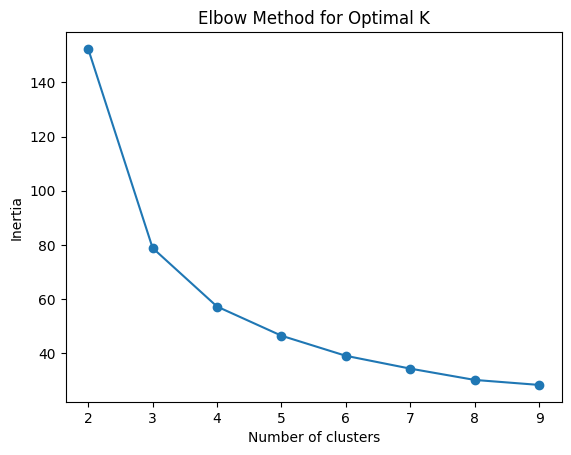

In [14]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load sample dataset (replace this with your own data if needed)
data = load_iris()
X = data.data

inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [16]:

df.head()

,Category,Name,Type,Rating,Cost,Sale Cost,Description
0,Assault Rifles,Assault Rifle Bullets,,3.0,6.0,22000.0,
1,Assault Rifles,OCP-11,Full-Auto Assaut Rifle,1.0,15000.0,22000.0,
2,Assault Rifles,416,Full-Auto Assaut Rifle,2.0,15000.0,22000.0,The 416 is a well-built German assaut rifle. A...
3,Assault Rifles,417,Burst-Fire Assault Rifle,3.0,7500.0,22000.0,The 417 is a German-made semi-automatic assaul...
4,Assault Rifles,AK-47,Full-Auto Assaut Rifle,3.0,15000.0,22000.0,The AK-47 is known for its durability and simp...


In [17]:
print(X.shape)
print(df.shape)

(150, 4)
(36, 7)


In [22]:
print(df.head())
print(df.columns)
print(X.shape)

         Category                   Name                      Type  Rating  \
0  Assault Rifles  Assault Rifle Bullets                               3.0   
1  Assault Rifles                 OCP-11    Full-Auto Assaut Rifle     1.0   
2  Assault Rifles                    416    Full-Auto Assaut Rifle     2.0   
3  Assault Rifles                    417  Burst-Fire Assault Rifle     3.0   
4  Assault Rifles                  AK-47    Full-Auto Assaut Rifle     3.0   

      Cost  Sale Cost                                        Description  
0      6.0    22000.0                                                     
1  15000.0    22000.0                                                     
2  15000.0    22000.0  The 416 is a well-built German assaut rifle. A...  
3   7500.0    22000.0  The 417 is a German-made semi-automatic assaul...  
4  15000.0    22000.0  The AK-47 is known for its durability and simp...  
Index(['Category', 'Name', 'Type', 'Rating', 'Cost', 'Sale Cost',
       'Descrip

In [24]:
if "cluster" in df.columns:
    for i in range(k):
        print(f"\n🔹 Cluster {i}")
        display(df[df["cluster"] == i].head(5))
else:
    print("No 'cluster' column found in df")

No 'cluster' column found in df
